<a href="https://colab.research.google.com/github/hardik-05/Fid-Case-Study/blob/main/Asset_class_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

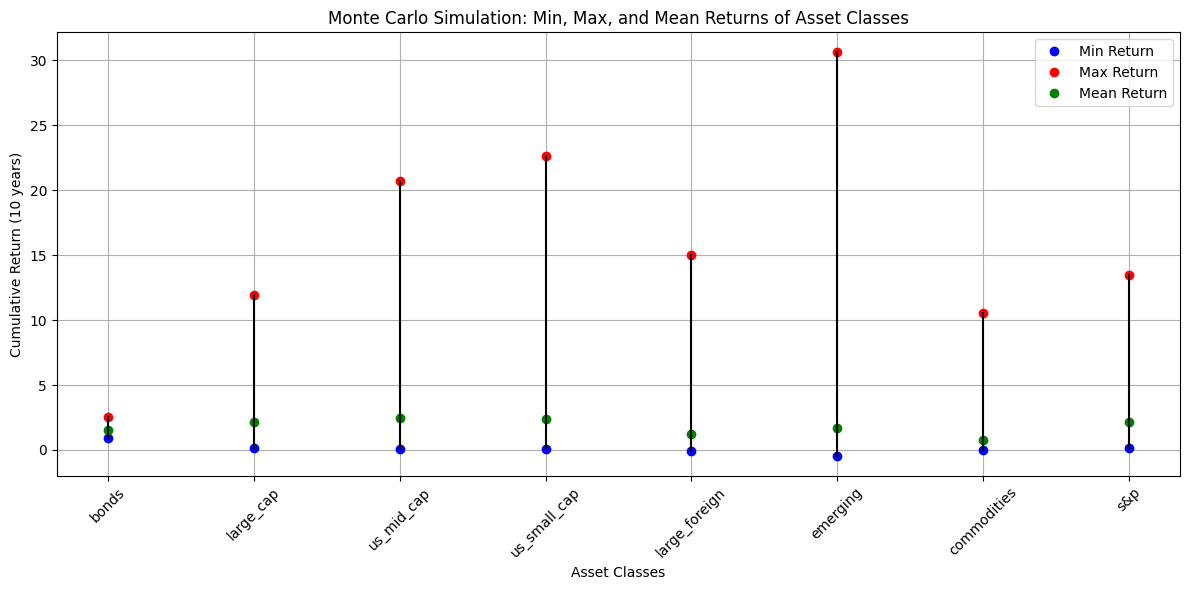

Asset Class | Min Return | Max Return | Mean Return
-------------------------------------------------------
bonds        |       0.92 |       2.51 |        1.54
large_cap    |       0.17 |      11.93 |        2.13
us_mid_cap   |       0.10 |      20.69 |        2.49
us_small_cap |       0.05 |      22.62 |        2.42
large_foreign |      -0.06 |      15.03 |        1.25
emerging     |      -0.43 |      30.61 |        1.72
commodities  |       0.01 |      10.56 |        0.77
s&p          |       0.16 |      13.50 |        2.14


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Given data
asset_classes = ['bonds', 'large_cap', 'us_mid_cap', 'us_small_cap', 'large_foreign', 'emerging', 'commodities', 's&p']
average_returns = [4.44, 7.85, 9.55, 9.22, 2.26, 5.57, -2.62, 7.89]
std_10_yrs = [3.29, 14.32, 17.68, 19.55, 18.21, 23.60, 18.11, 14.74]

# Monte Carlo simulation parameters
num_simulations = 1000000
time_horizon = 10  # years

# Perform Monte Carlo simulation
simulated_returns = []
for mu, sigma in zip(average_returns, std_10_yrs):
    annual_returns = norm.rvs(loc=mu, scale=sigma, size=(num_simulations, time_horizon))
    cumulative_returns = np.cumprod(1 + annual_returns / 100, axis=1)
    final_returns = cumulative_returns[:, -1]
    simulated_returns.append(final_returns)

# Calculate statistics
min_returns = [np.min(returns) for returns in simulated_returns]
max_returns = [np.max(returns) for returns in simulated_returns]
mean_returns = [np.mean(returns) for returns in simulated_returns]

# Plotting
plt.figure(figsize=(12, 6))
x = range(len(asset_classes))

plt.plot(x, min_returns, 'bo', label='Min Return')
plt.plot(x, max_returns, 'ro', label='Max Return')
plt.plot(x, mean_returns, 'go', label='Mean Return')

for i, asset in enumerate(asset_classes):
    plt.plot([i, i], [min_returns[i], max_returns[i]], 'k-')

plt.xlabel('Asset Classes')
plt.ylabel('Cumulative Return (10 years)')
plt.title('Monte Carlo Simulation: Min, Max, and Mean Returns of Asset Classes')
plt.xticks(x, asset_classes, rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print numerical results
print("Asset Class | Min Return | Max Return | Mean Return")
print("-" * 55)
for asset, min_ret, max_ret, mean_ret in zip(asset_classes, min_returns, max_returns, mean_returns):
    print(f"{asset:<12} | {min_ret:10.2f} | {max_ret:10.2f} | {mean_ret:11.2f}")